# Classifing with decision trees, random forests, pruning, interpretability, k-NN

In [35]:
import pandas as pd

RNG = 42

## Data exploration

In [36]:
from sklearn.datasets._openml import fetch_openml

dataset_name = "Adult Census Income"

try:
    ds = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
    df = ds.frame
    df["income"] = (df["class"] == ">50K").astype(int)
    df = df.drop(columns=["class"])
    target_col = "income"
    print(
        f"Dataset '{dataset_name}' loaded successfully: {df.shape[0]} samples, {df.shape[1]} features."
    )
    print(f"Class distribution:\n{df[target_col].value_counts()}")
    print(f"Baseline = {df[target_col].mean():.3f}")
except Exception as e:
    print(f"Error fetching dataset: {e}")
    df = None

df.head()

Dataset 'Adult Census Income' loaded successfully: 48842 samples, 15 features.
Class distribution:
income
0    37155
1    11687
Name: count, dtype: int64
Baseline = 0.239


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [37]:
info = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isnull().sum(),
        "missing%": df.isnull().mean() * 100,
        "nunique": df.nunique(),
    }
)
info

,dtype,missing,missing%,nunique
age,int64,0,0.000000,74
workclass,category,2799,5.730724,8
fnlwgt,int64,0,0.000000,28523
education,category,0,0.000000,16
education-num,int64,0,0.000000,16
marital-status,category,0,0.000000,7
occupation,category,2809,5.751198,14
relationship,category,0,0.000000,6
race,category,0,0.000000,5
sex,category,0,0.000000,2


In [38]:
num_cols = df.select_dtypes(include=["number"]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"({len(num_cols)}) Numerical columns: {num_cols}")
print(f"({len(cat_cols)}) Categorical columns: {cat_cols}")

(6) Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
(8) Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [39]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


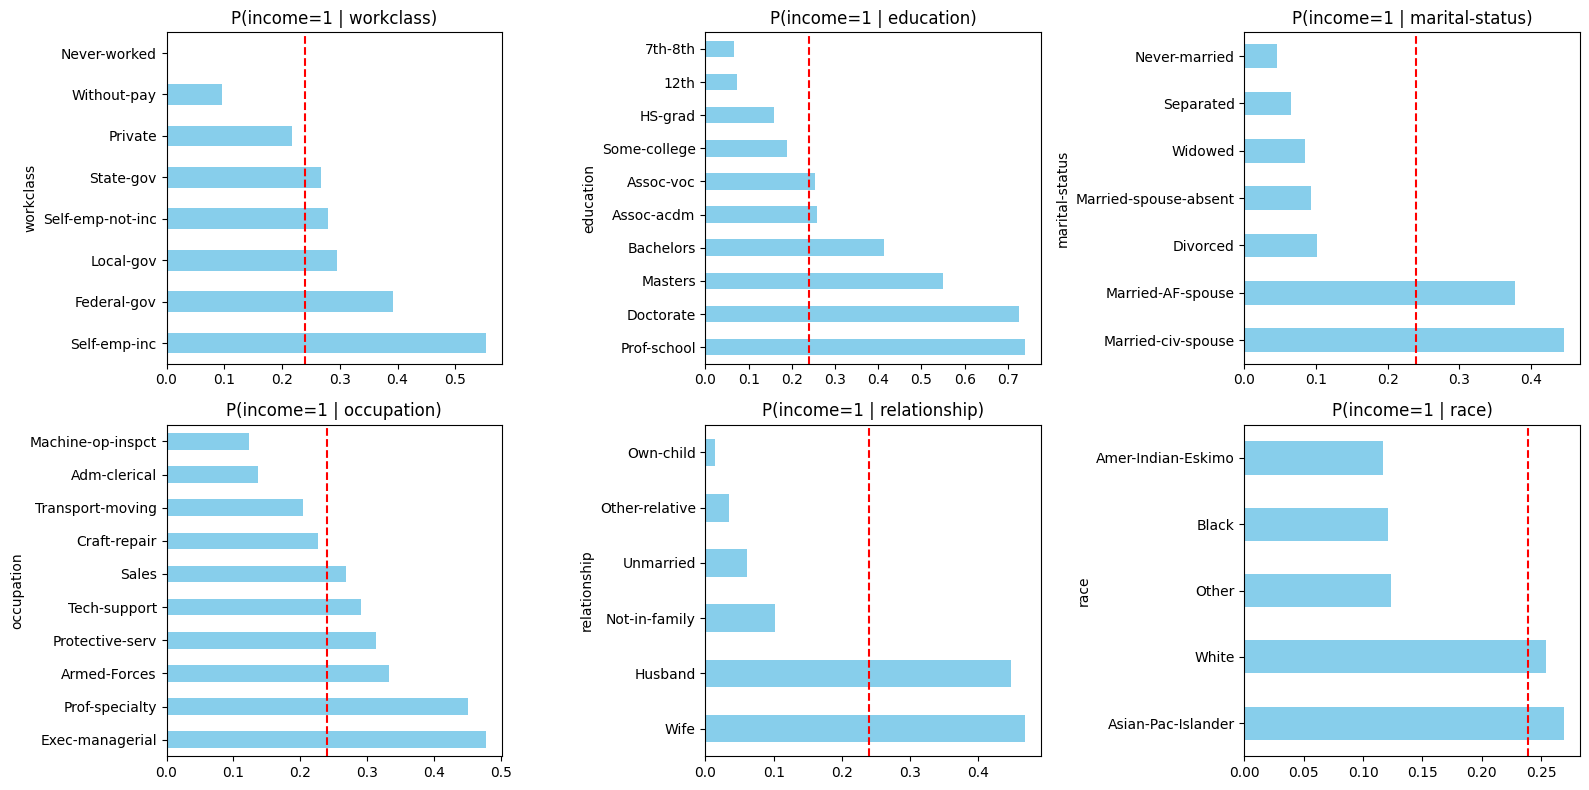

In [40]:
import matplotlib.pyplot as plt
import numpy as np

if cat_cols:
    fig, axes = plt.subplots(2, min(3, len(cat_cols)), figsize=(16, 8))
    axes = np.array(axes).ravel()
    for i, col in enumerate(cat_cols[:6]):
        vc = df.groupby(col)[target_col].mean().sort_values(ascending=False).head(10)
        vc.plot(
            kind="barh", ax=axes[i], title=f"{col} vs {target_col}", color="skyblue"
        )
        axes[i].axvline(
            df[target_col].mean(), color="red", linestyle="--", label="Baseline"
        )
        axes[i].set_title(f"P({target_col}=1 | {col})")
        axes[i].set_xlabel("")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

## Preprocessing

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
    ]
)
preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

feature_names = num_cols + cat_cols
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RNG
)


print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Class distribution in train: {y_train.value_counts(normalize=True)}")
print(f"Class distribution in test: {y_test.value_counts(normalize=True)}")

Training set: 36631 samples, 14 features
Test set: 12211 samples, 14 features
Class distribution in train: income
0    0.760722
1    0.239278
Name: proportion, dtype: float64
Class distribution in test: income
0    0.760708
1    0.239292
Name: proportion, dtype: float64


In [42]:
from sklearn.tree import DecisionTreeClassifier

base_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RNG)),
    ]
)

base_pipeline.fit(X_train, y_train)
print("Full tree:")
print(f"\tdepth: {base_pipeline.named_steps['clf'].get_depth()}")
print(f"\tleaves: {base_pipeline.named_steps['clf'].get_n_leaves()}")
print(f"\tTrain accuracy: {base_pipeline.score(X_train, y_train):.4f}")
print(f"\tTest accuracy: {base_pipeline.score(X_test, y_test):.4f}")

Full tree:
	depth: 44
	leaves: 5450
	Train accuracy: 0.9999
	Test accuracy: 0.8178


In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

depths = list(range(1, 21))
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)
cv_scores = []

for d in depths:
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("clf", DecisionTreeClassifier(max_depth=d, random_state=RNG)),
        ]
    )
    s = cross_val_score(
        pipeline, X_train, y_train, cv=kf, scoring="balanced_accuracy", n_jobs=-1
    )
    cv_scores.append((s.mean(), s.std()))

In [44]:
print(
    f"Best depth: {depths[np.argmax([s[0] for s in cv_scores])]} with CV score: {max(cv_scores)[0]:.4f} ± {max(cv_scores)[1]:.4f}"
)

Best depth: 10 with CV score: 0.7785 ± 0.0117


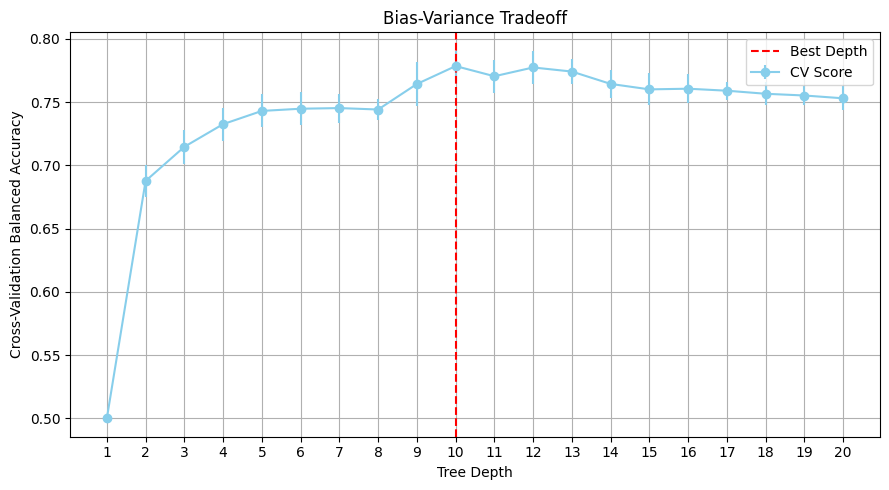

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    depths,
    [s[0] for s in cv_scores],
    yerr=[s[1] for s in cv_scores],
    marker="o",
    color="skyblue",
    label="CV Score",
)
ax.axvline(
    depths[np.argmax([s[0] for s in cv_scores])],
    color="red",
    linestyle="--",
    label="Best Depth",
)
ax.set_xlabel("Tree Depth")
ax.set_ylabel("Cross-Validation Balanced Accuracy")
ax.set_title("Bias-Variance Tradeoff")
ax.legend()
ax.set_xticks(depths)
plt.grid()
plt.tight_layout()
plt.show()

In [50]:
cpp_alphas = base_pipeline.named_steps["clf"].cost_complexity_pruning_path(
    preprocessor.fit_transform(X_train), y_train
)
ccp_alphas, impurities = cpp_alphas.ccp_alphas, cpp_alphas.impurities
print(f"Number of effective alphas: {len(ccp_alphas)}")
print(f"Alphas: {ccp_alphas[:5]} ... {ccp_alphas[-5:]}")

Number of effective alphas: 1994
Alphas: [0.00000000e+00 9.09976068e-06 9.09976068e-06 1.31246548e-05
 1.32230897e-05] ... [0.01190093 0.01233601 0.02006751 0.02509139 0.05987019]


In [ ]:
stats = []

for alpha in ccp_alphas:  # Test every 10th alpha for speed
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("clf", DecisionTreeClassifier(random_state=RNG, ccp_alpha=alpha)),
        ]
    )
    s = cross_val_score(
        pipeline, X_train, y_train, cv=kf, scoring="balanced_accuracy", n_jobs=-1
    )
    stats.append((alpha, s.mean(), s.std()))
    print(f"Alpha: {alpha:.5f}, CV Score: {s.mean():.4f} ± {s.std():.4f}")